
## Metodología CRISP-DM: Fases 1 y 2

**Asignatura:** Minería de Datos_002D  
**Integrantes:**  
- José Oporto  
- Raúl Ibarra  

**Fecha:** 30/03/2026
``

# 1. Introducción

El presente informe tiene como objetivo analizar un conjunto de datos meteorológicos correspondientes a distintas ubicaciones de Australia, utilizando la metodología CRISP-DM (Cross Industry Standard Process for Data Mining), enfocándose específicamente en las fases de conocimiento del negocio y conocimiento de los datos.

El dataset contiene observaciones diarias de variables climáticas relevantes, tales como temperatura, humedad, presión atmosférica, velocidad del viento y precipitaciones. Además, incorpora la variable objetivo RainTomorrow, la cual indica si se registrará lluvia al día siguiente.

El propósito de este análisis es identificar patrones relevantes en el comportamiento climático y generar información útil que permita apoyar la toma de decisiones.

# 2. Conocimiento del Negocio

## 2.1 Identificación del Problema

Australia presenta una gran diversidad climática debido a su extensión geográfica y variedad de condiciones ambientales, lo que dificulta la predicción precisa de fenómenos meteorológicos como la lluvia.

El problema principal consiste en identificar los factores climáticos que influyen en la ocurrencia de precipitaciones al día siguiente, representado por la variable RainTomorrow, con el fin de apoyar la toma de decisiones en sectores como la agricultura, el transporte y la gestión de riesgos.

## 2.2 Definición de Objetivos y KPIs

**Objetivo general:**  
Analizar el dataset meteorológico para identificar patrones y relaciones entre variables que permitan comprender la ocurrencia de lluvia.

**Objetivos específicos:**  
- Analizar las principales variables climáticas  
- Identificar relaciones entre variables meteorológicas  
- Detectar valores atípicos y datos faltantes  
- Evaluar la influencia de distintas variables en la ocurrencia de lluvia  

**KPIs definidos:**  
- Porcentaje de días con lluvia (RainTomorrow)  
- Promedio de precipitación diaria  
- Promedio de humedad  
- Temperaturas promedio  
- Velocidad promedio del viento  


# 3. Conocimiento de los Datos
## 3.1 Carga del conjunto de datos

Se carga el conjunto de datos meteorológicos y se visualizan las primeras observaciones para verificar la correcta lectura del archivo.

In [9]:
from google.colab import files
files.upload()


Output hidden; open in https://colab.research.google.com to view.

In [10]:
import pandas as pd
df = pd.read_csv("weatherAUS.csv")
df.head()

,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,...,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RISK_MM,RainTomorrow
0,2008-12-01,Albury,13.4,22.9,0.6,NaN,NaN,W,44.0,W,...,22.0,1007.7,1007.1,8.0,NaN,16.9,21.8,No,0.0,No
1,2008-12-02,Albury,7.4,25.1,0.0,NaN,NaN,WNW,44.0,NNW,...,25.0,1010.6,1007.8,NaN,NaN,17.2,24.3,No,0.0,No
2,2008-12-03,Albury,12.9,25.7,0.0,NaN,NaN,WSW,46.0,W,...,30.0,1007.6,1008.7,NaN,2.0,21.0,23.2,No,0.0,No
3,2008-12-04,Albury,9.2,28.0,0.0,NaN,NaN,NE,24.0,SE,...,16.0,1017.6,1012.8,NaN,NaN,18.1,26.5,No,1.0,No
4,2008-12-05,Albury,17.5,32.3,1.0,NaN,NaN,W,41.0,ENE,...,33.0,1010.8,1006.0,7.0,8.0,17.8,29.7,No,0.2,No


## 3.2 Estructura y naturaleza de los datos

En esta sección se analiza la estructura del conjunto de datos, identificando el número de registros, columnas y tipos de variables presentes. Este análisis permite comprender la naturaleza de los datos y determinar el tipo de análisis que puede realizarse.
``

In [15]:

df.shape
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 142193 entries, 0 to 142192
Data columns (total 24 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   Date           142193 non-null  object 
 1   Location       142193 non-null  object 
 2   MinTemp        141556 non-null  float64
 3   MaxTemp        141871 non-null  float64
 4   Rainfall       140787 non-null  float64
 5   Evaporation    81350 non-null   float64
 6   Sunshine       74377 non-null   float64
 7   WindGustDir    132863 non-null  object 
 8   WindGustSpeed  132923 non-null  float64
 9   WindDir9am     132180 non-null  object 
 10  WindDir3pm     138415 non-null  object 
 11  WindSpeed9am   140845 non-null  float64
 12  WindSpeed3pm   139563 non-null  float64
 13  Humidity9am    140419 non-null  float64
 14  Humidity3pm    138583 non-null  float64
 15  Pressure9am    128179 non-null  float64
 16  Pressure3pm    128212 non-null  float64
 17  Cloud9am       88536 non-null

3.3 Estadística descriptiva

A partir de la estadística descriptiva se observa una alta variabilidad en variables como precipitación, temperatura y humedad.
Por ejemplo, la variable Rainfall presenta un valor mínimo de 0 mm y un valor máximo elevado, lo que indica la presencia de días sin lluvia y eventos de precipitación intensa.


In [16]:
df.describe().round(2).style.background_gradient(cmap='Blues')

,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustSpeed,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RISK_MM
count,141556.000000,141871.000000,140787.000000,81350.000000,74377.000000,132923.000000,140845.000000,139563.000000,140419.000000,138583.000000,128179.000000,128212.000000,88536.000000,85099.000000,141289.000000,139467.000000,142193.000000
mean,12.190000,23.230000,2.350000,5.470000,7.620000,39.980000,14.000000,18.640000,68.840000,51.480000,1017.650000,1015.260000,4.440000,4.500000,16.990000,21.690000,2.360000
std,6.400000,7.120000,8.470000,4.190000,3.780000,13.590000,8.890000,8.800000,19.050000,20.800000,7.110000,7.040000,2.890000,2.720000,6.490000,6.940000,8.480000
min,-8.500000,-4.800000,0.000000,0.000000,0.000000,6.000000,0.000000,0.000000,0.000000,0.000000,980.500000,977.100000,0.000000,0.000000,-7.200000,-5.400000,0.000000
25%,7.600000,17.900000,0.000000,2.600000,4.900000,31.000000,7.000000,13.000000,57.000000,37.000000,1012.900000,1010.400000,1.000000,2.000000,12.300000,16.600000,0.000000
50%,12.000000,22.600000,0.000000,4.800000,8.500000,39.000000,13.000000,19.000000,70.000000,52.000000,1017.600000,1015.200000,5.000000,5.000000,16.700000,21.100000,0.000000
75%,16.800000,28.200000,0.800000,7.400000,10.600000,48.000000,19.000000,24.000000,83.000000,66.000000,1022.400000,1020.000000,7.000000,7.000000,21.600000,26.400000,0.800000
max,33.900000,48.100000,371.000000,145.000000,14.500000,135.000000,130.000000,87.000000,100.000000,100.000000,1041.000000,1039.600000,9.000000,9.000000,40.200000,46.700000,371.000000


## 3.4 Identificación de valores nulos


Se observa la presencia de valores faltantes en varias variables, especialmente en evaporación, horas de sol y dirección del viento.
Estos valores deberán ser tratados en etapas posteriores del proceso de preparación de datos.


In [13]:
df.isnull().sum().sort_values(ascending=False).to_frame(
    name='Cantidad de valores nulos'
).style.background_gradient(cmap='Reds')



,Cantidad de valores nulos
Sunshine,67816
Evaporation,60843
Cloud3pm,57094
Cloud9am,53657
Pressure9am,14014
Pressure3pm,13981
WindDir9am,10013
WindGustDir,9330
WindGustSpeed,9270
WindDir3pm,3778



### 3.4 Limpieza de los Datos

En esta etapa se evalúa el impacto de los valores faltantes presentes en el conjunto de datos.
Eliminar registros con valores nulos podría reducir de forma significativa la cantidad de información disponible, afectando la representatividad del análisis.
Por este motivo, en esta fase no se realiza una limpieza definitiva, sino que se analiza el impacto potencial de estos valores.


In [14]:
# Evaluar el impacto de los valores nulos sin modificar el dataset

total_registros = df.shape[0]
registros_con_nulos = df.isnull().any(axis=1).sum()

print(f"Total de registros: {total_registros}")
print(f"Registros con al menos un valor nulo: {registros_con_nulos}")
print(f"Porcentaje de registros afectados: {round(registros_con_nulos / total_registros * 100, 2)} %")

Total de registros: 142193
Registros con al menos un valor nulo: 85773
Porcentaje de registros afectados: 60.32 %


### 3.5 Identificación de valores atípicos

Se utilizan diagramas de caja (boxplot) para identificar la presencia de valores atípicos en variables numéricas del conjunto de datos.

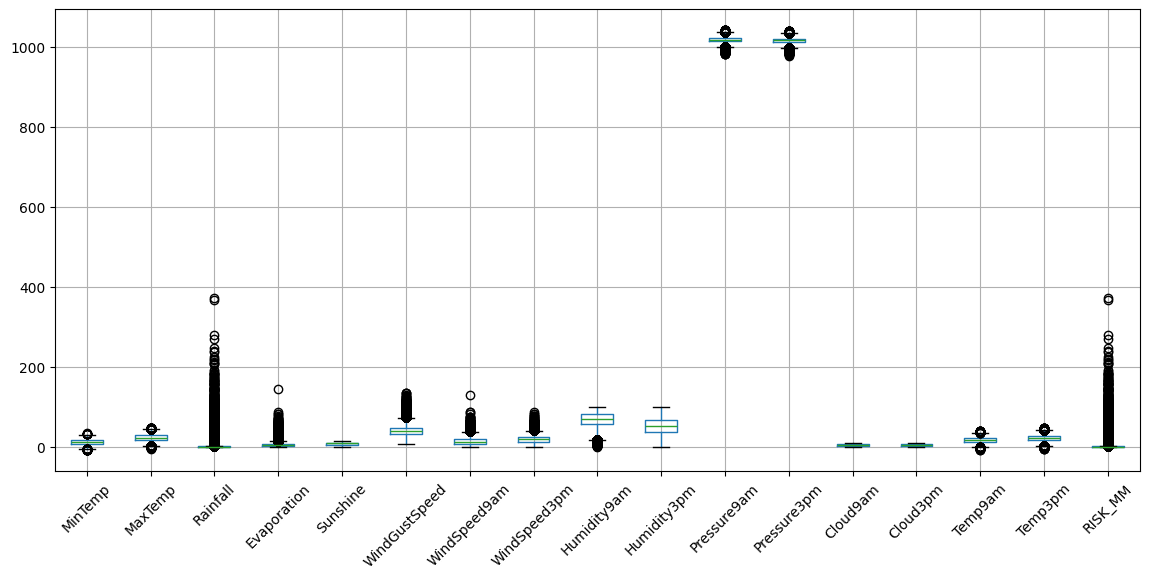

In [ ]:
import matplotlib.pyplot as plt

df.boxplot(figsize=(14,6))
plt.xticks(rotation=45)
plt.show()


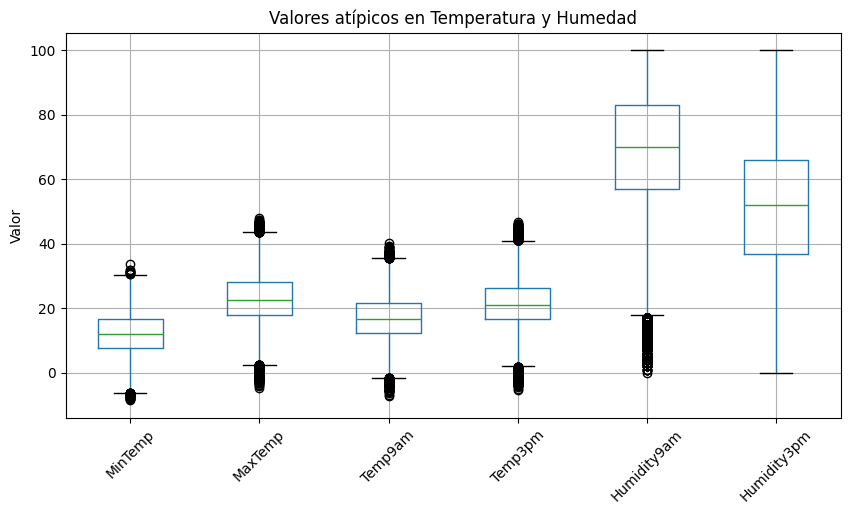

In [ ]:
import matplotlib.pyplot as plt

vars_temp_hum = [
    'MinTemp', 'MaxTemp',
    'Temp9am', 'Temp3pm',
    'Humidity9am', 'Humidity3pm'
]

df[vars_temp_hum].boxplot(figsize=(10,5))
plt.title('Valores atípicos en Temperatura y Humedad')
plt.ylabel('Valor')
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

In [ ]:
vars_lluvia_viento = [
    'Rainfall',
    'WindGustSpeed',
    'WindSpeed9am',
    'WindSpeed3pm'
]

df[vars_lluvia_viento].boxplot(figsize=(10,5))
plt.title('Valores atípicos en Precipitación y Velocidad del Viento')
plt.ylabel('Valor')
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

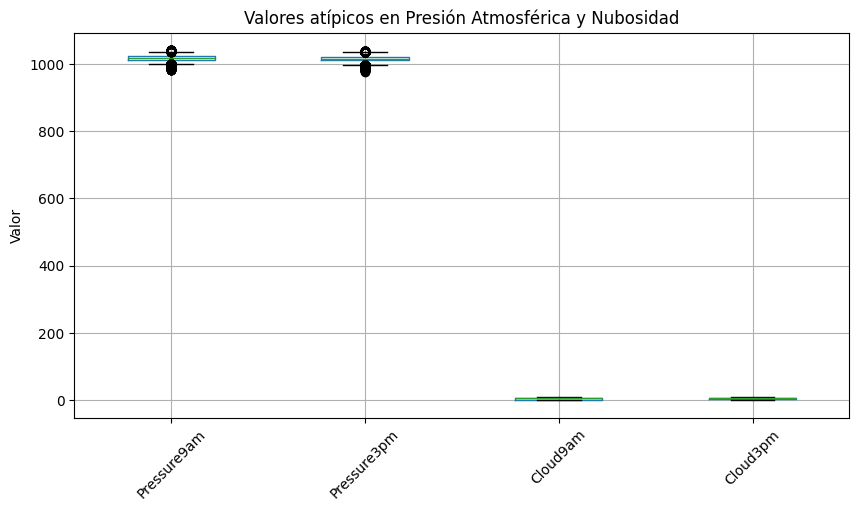

In [ ]:
vars_presion_nubes = [
    'Pressure9am',
    'Pressure3pm',
    'Cloud9am',
    'Cloud3pm'
]

df[vars_presion_nubes].boxplot(figsize=(10,5))
plt.title('Valores atípicos en Presión Atmosférica y Nubosidad')
plt.ylabel('Valor')
plt.xticks(rotation=45)
plt.grid(True)
plt.show()


### 3.7 Identificación de correlaciones entre las variables

Se analiza la relación entre las variables numéricas del conjunto de datos mediante una matriz de correlación, con el objetivo de identificar asociaciones relevantes que permitan comprender el comportamiento climático y su relación con la ocurrencia de lluvia.
``

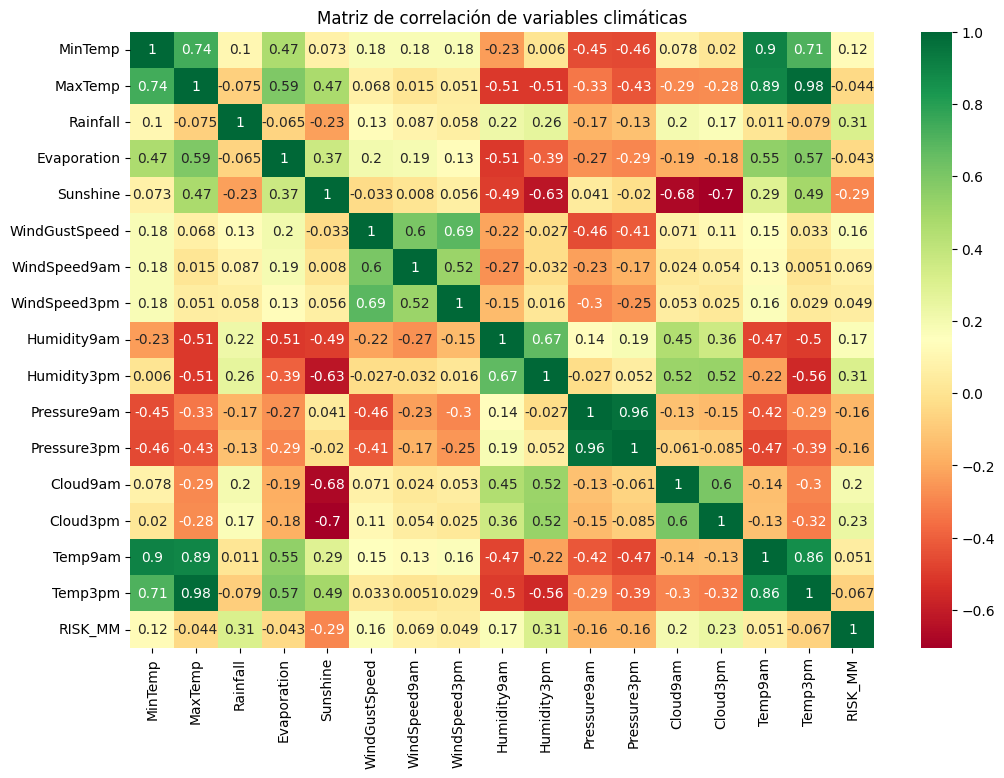

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

corr = df.corr(numeric_only=True)

plt.figure(figsize=(12,8))
sns.heatmap(corr, annot=True, cmap='RdYlGn')
plt.title('Matriz de correlación de variables climáticas')
plt.show()

A partir del análisis de la matriz de correlación, se observa que la humedad presenta una relación positiva con la ocurrencia de lluvia, mientras que la presión atmosférica muestra una relación inversa.
Asimismo, se identifican correlaciones esperadas entre variables relacionadas, como temperaturas mínimas y máximas, lo que valida la coherencia de los datos.
Estas relaciones permiten comprender mejor los factores climáticos que influyen en la variable objetivo RainTomorrow.


### 3.8 Identificación de Insights Relevantes

A partir del análisis exploratorio realizado, se identifican los siguientes insights relevantes:

- La humedad relativa, especialmente durante la tarde, presenta una relación positiva con la ocurrencia de lluvia, indicando que valores elevados de humedad aumentan la probabilidad de precipitaciones.
- La presión atmosférica muestra una relación inversa con la lluvia, donde valores de presión más bajos están asociados a condiciones meteorológicas más inestables.
- La precipitación actual influye en la probabilidad de lluvia futura, lo que sugiere una continuidad en las condiciones climáticas de un día a otro.
- La presencia de valores atípicos en variables como precipitación y velocidad del viento refleja la ocurrencia de eventos climáticos extremos, característicos de los datos meteorológicos.

### 3.9 Propuesta de Pasos a Seguir

En base a los resultados obtenidos en las fases de Conocimiento del Negocio y Conocimiento de los Datos, se proponen los siguientes pasos a seguir:

- Aplicar técnicas de imputación para el tratamiento de valores faltantes, con el fin de preservar la mayor cantidad de información posible.
- Analizar en mayor profundidad las variables categóricas, como la ubicación geográfica y la dirección del viento.
- Implementar modelos de machine learning para predecir la variable RainTomorrow.
- Evaluar algoritmos de clasificación como regresión logística y árboles de decisión, utilizando métricas de desempeño adecuadas.
